# DeepFake Detection — MTCNN + Xception (v2)
**Pipeline:** Video → MTCNN crop faces → Xception classify → Evaluate → Demo

In [1]:
!pip install mtcnn lz4 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 25.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 66.0 MB/s eta 0:00:00


## 1. Cấu hình & Import

In [ ]:
import os
import cv2
import glob
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import (
    Input, Conv2D, SeparableConv2D, MaxPooling2D,
    GlobalAveragePooling2D, BatchNormalization,
    ReLU, Add, Dense, Dropout
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import Xception
from tensorflow.keras.models import Model
from mtcnn.mtcnn import MTCNN
import datetime

import warnings

warnings.filterwarnings("ignore")

# Cấu hình 
FF_REAL_PATH = "/kaggle/input/datasets/hungle3401/faceforensics/FF++/real"
FF_FAKE_PATH = "/kaggle/input/datasets/hungle3401/faceforensics/FF++/fake"

OUTPUT_FRAME_SIZE = (299, 299)  # Xception yêu cầu 299x299
FRAME_COUNT       = 10          # Số frame / video
MAX_VIDEOS        = 400         # Giới hạn mỗi class
FACE_MARGIN       = 15          # Padding khi crop mặt

print("✓ Import xong, TF version:", tf.__version__)

2026-04-12 13:01:58.651432: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775998918.835692      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775998918.888782      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775998919.296966      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775998919.297011      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775998919.297014      55 computation_placer.cc:177] computation placer alr

✓ Import xong, TF version: 2.19.0


## 2. Trích xuất & Crop mặt bằng MTCNN
> **BUG đã fix:** code gốc chỉ lấy `results[0]` (mặt đầu tiên theo thứ tự detect), không lọc theo confidence. Thêm lọc `confidence >= 0.95` để bỏ false positive.

In [ ]:
detector = MTCNN()

def extract_faces_from_video(video_path, mtcnn_detector, n_frames=20,
                        output_size=(299,299), margin=15,
                        min_confidence=0.90):
    """
    Lấy frame:
    1. Sample thưa toàn bộ video để tính motion score
    2. Ưu tiên frame có motion cao (chuyển động = artifacts rõ hơn)
    3. Chỉ giữ n_frames frame tốt nhất
    """
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total == 0:
        cap.release()
        return np.array([])

    #Bước 1: đọc frame thưa để tính motion
    SAMPLE_N   = min(60, total)
    sample_step = max(total // SAMPLE_N, 1)
    
    sampled_frames = []
    sampled_indices = []
    for i in range(SAMPLE_N):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i * sample_step)
        ret, frame = cap.read()
        if ret:
            sampled_frames.append(frame)
            sampled_indices.append(i * sample_step)

    #Bước 2: tính motion score giữa frame liên tiếp
    motion_scores = [0]  
    for i in range(1, len(sampled_frames)):
        prev = cv2.cvtColor(sampled_frames[i-1], cv2.COLOR_BGR2GRAY)
        curr = cv2.cvtColor(sampled_frames[i],   cv2.COLOR_BGR2GRAY)
        diff = cv2.absdiff(prev, curr)
        motion_scores.append(diff.mean())

    #Bước 3: chọn top n_frames frame có motion cao nhất
    top_indices = np.argsort(motion_scores)[-n_frames:]
    top_indices = sorted(top_indices)  # giữ thứ tự thời gian

    #Bước 4: detect mặt trên các frame đã chọn 
    cropped_faces = []
    for idx in top_indices:
        frame     = sampled_frames[idx]
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results   = mtcnn_detector.detect_faces(rgb_frame)

        valid = [r for r in results if r['confidence'] >= min_confidence]
        if not valid:
            continue
        best = max(valid, key=lambda r: r['box'][2] * r['box'][3])

        x, y, w, h = best['box']
        x1 = max(0, x - margin);      y1 = max(0, y - margin)
        x2 = min(frame.shape[1], x + w + margin)
        y2 = min(frame.shape[0], y + h + margin)

        face = rgb_frame[y1:y2, x1:x2]
        if face.size == 0:
            continue
        cropped_faces.append(
            cv2.resize(face, output_size).astype(np.float32) / 255.0
        )

    cap.release()

    # Pad nếu thiếu
    if 0 < len(cropped_faces) < n_frames:
        pad = [cropped_faces[-1]] * (n_frames - len(cropped_faces))
        cropped_faces.extend(pad)

    return np.array(cropped_faces[:n_frames])

I0000 00:00:1775998940.764731      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


## 3. Build dataset

In [4]:
data, labels = [], []

real_files = sorted(glob.glob(os.path.join(FF_REAL_PATH, '*.mp4')))[:MAX_VIDEOS]
fake_files = sorted(glob.glob(os.path.join(FF_FAKE_PATH, '*.mp4')))[:MAX_VIDEOS]
print(f"REAL: {len(real_files)} videos | FAKE: {len(fake_files)} videos")

for label, file_list in [(0, real_files), (1, fake_files)]:
    tag = 'REAL' if label == 0 else 'FAKE'
    print(f"\nProcessing {tag}...")
    skipped = 0
    for vpath in tqdm(file_list):
        faces = extract_faces_from_video(vpath, detector, FRAME_COUNT, OUTPUT_FRAME_SIZE, FACE_MARGIN)
        # Chỉ giữ video có đủ FRAME_COUNT frame mặt detect được
        if len(faces) == FRAME_COUNT:
            data.append(faces)
            labels.append(label)
        else:
            skipped += 1
    print(f"  → {len([l for l in labels if l == label])} videos OK, {skipped} bị skip (không đủ mặt)")

data   = np.array(data,   dtype=np.float32)
labels = np.array(labels, dtype=np.int32)
print(f"\nDataset shape: {data.shape}  |  Labels: {np.bincount(labels)}")

REAL: 200 videos | FAKE: 200 videos

Processing REAL...


100%|██████████| 200/200 [2:07:43<00:00, 38.32s/it]  


  → 200 videos OK, 0 bị skip (không đủ mặt)

Processing FAKE...


100%|██████████| 200/200 [2:05:01<00:00, 37.51s/it]  


  → 200 videos OK, 0 bị skip (không đủ mặt)

Dataset shape: (400, 10, 299, 299, 3)  |  Labels: [200 200]


## 4. Train / Val / Test split

In [5]:
# Stratified split: 70% train, 15% val, 15% test
X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    data, labels, test_size=0.30, random_state=42, stratify=labels
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=42, stratify=y_tmp
)

#del data  # giải phóng RAM

np.savez_compressed(
    '/kaggle/working/processed_deepfake_data.npz',
    X_train=X_tr, y_train=y_tr,
    X_val=X_val,  y_val=y_val,
    X_test=X_test, y_test=y_test
)

print(f"Train : {X_tr.shape}  labels={np.bincount(y_tr)}")
print(f"Val   : {X_val.shape}  labels={np.bincount(y_val)}")
print(f"Test  : {X_test.shape}  labels={np.bincount(y_test)}")

Train : (280, 10, 299, 299, 3)  labels=[140 140]
Val   : (60, 10, 299, 299, 3)  labels=[30 30]
Test  : (60, 10, 299, 299, 3)  labels=[30 30]


## 5. Load lại data (bỏ qua nếu chạy liên tục)

In [6]:
d = np.load('/kaggle/working/processed_deepfake_data.npz')
X_tr   = d['X_train'];  y_tr   = d['y_train']
X_val  = d['X_val'];    y_val  = d['y_val']
X_test = d['X_test'];   y_test = d['y_test']
FRAME_COUNT = X_tr.shape[1]
print("Loaded:", X_tr.shape, X_val.shape, X_test.shape)

Loaded: (280, 10, 299, 299, 3) (60, 10, 299, 299, 3) (60, 10, 299, 299, 3)


## 6. Visualize mẫu dữ liệu

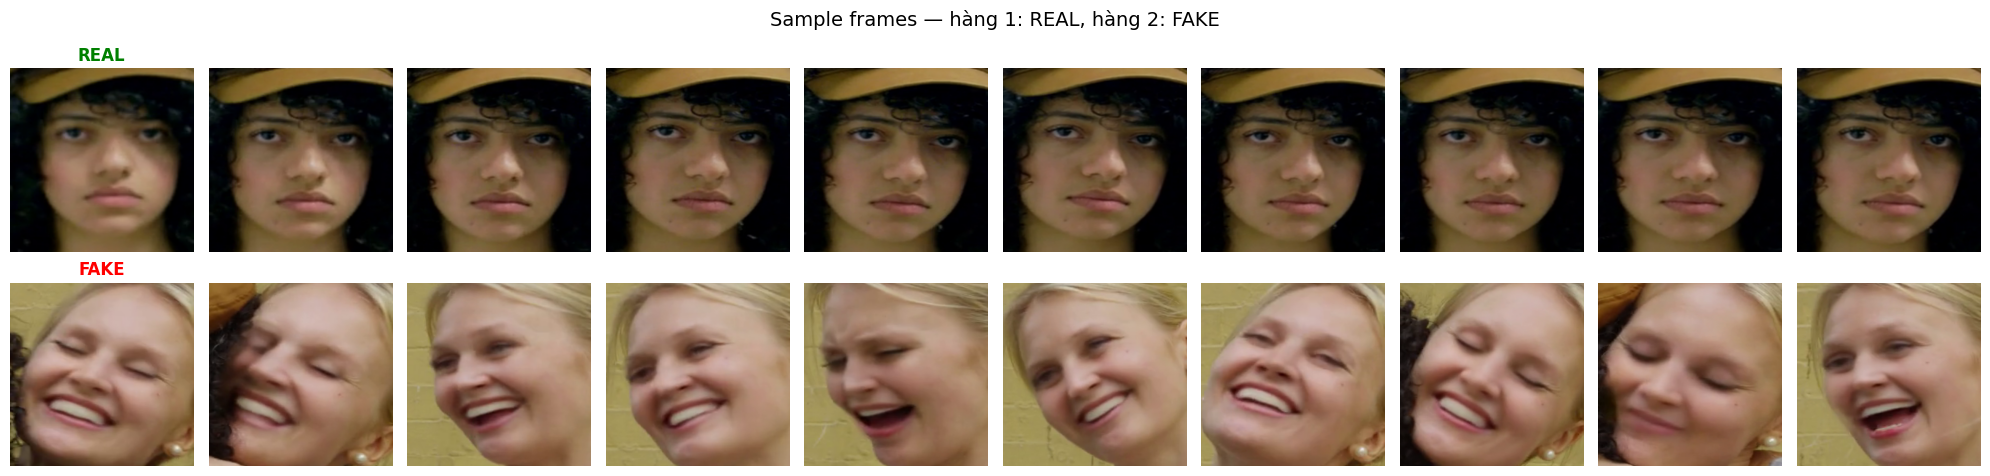

In [7]:
label_map = {0: 'REAL', 1: 'FAKE'}

fig, axes = plt.subplots(2, FRAME_COUNT, figsize=(20, 5))
for row, cls in enumerate([0, 1]):
    idx = np.where(y_tr == cls)[0][0]
    for col, frame in enumerate(X_tr[idx]):
        axes[row, col].imshow(frame)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(label_map[cls], fontsize=12, fontweight='bold',
                                     color='green' if cls == 0 else 'red')
plt.suptitle('Sample frames — hàng 1: REAL, hàng 2: FAKE', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Data Augmentation
> **NOTE:** Augmentation chỉ áp dụng cho train. Val/Test dùng raw data.
> Reshape `(videos, frames, H, W, C)` → `(videos×frames, H, W, C)` để dùng ImageDataGenerator.

In [9]:
BATCH_SIZE        = 32
n_tr, n_f, h, w, c = X_tr.shape

X_tr_flat  = X_tr.reshape(n_tr * n_f, h, w, c)
y_tr_flat  = np.repeat(y_tr, n_f)              # mỗi frame mang nhãn của video
y_tr_cat   = to_categorical(y_tr_flat, 2)

n_val = X_val.shape[0]
X_val_flat = X_val.reshape(n_val * n_f, h, w, c)
y_val_flat = np.repeat(y_val, n_f)
y_val_cat  = to_categorical(y_val_flat, 2)

n_test = X_test.shape[0]
X_test_flat = X_test.reshape(n_test * n_f, h, w, c)
y_test_flat = np.repeat(y_test, n_f)

train_datagen = ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=10,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.10,
    brightness_range=[0.85, 1.15],
    fill_mode='nearest'
)
train_gen = train_datagen.flow(X_tr_flat, y_tr_cat, batch_size=BATCH_SIZE, shuffle=True)

STEPS = len(X_tr_flat) // BATCH_SIZE
print(f"Train samples: {len(X_tr_flat)} | Steps/epoch: {STEPS}")
print(f"Val   samples: {len(X_val_flat)}")
print(f"Test  samples: {len(X_test_flat)}")

Train samples: 2800 | Steps/epoch: 87
Val   samples: 600
Test  samples: 600


## 8. Model

In [10]:
def get_callbacks(stage_name, patience=5):
    return [
        EarlyStopping(
            monitor='val_loss',
            patience=patience,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=1
        ),
        ModelCheckpoint(
            filepath=f'/kaggle/working/best_{stage_name}.keras',
            monitor='val_loss',
            save_best_only=True,
            verbose=1
        )
    ]


def build_full_model(num_classes=2, input_shape=(299, 299, 3), dropout=0.5):
    base = Xception(weights='imagenet', include_top=False, input_shape=input_shape)
    base.trainable = False

    x   = base.output
    x   = GlobalAveragePooling2D(name='avg_pool')(x)
    x   = Dropout(dropout)(x)
    out = Dense(num_classes, activation='softmax', name='predictions')(x)

    model = Model(inputs=base.input, outputs=out, name='xception_deepfake')
    return model, base


def unfreeze_top_n_layers(base_model, n):
    for layer in base_model.layers:
        layer.trainable = False
    for layer in base_model.layers[-n:]:
        layer.trainable = True

    trainable = sum(1 for l in base_model.layers if l.trainable)
    print(f"Trainable: {trainable} / {len(base_model.layers)} layers")


# Build
model, base = build_full_model()
model.summary(line_length=90)


83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "xception_deepfake"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)             ┃ Output Shape         ┃      Param # ┃ Connected to          ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer) │ (None, 299, 299, 3)  │            0 │ -                     │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ block1_conv1 (Conv2D)    │ (None, 149, 149, 32) │          864 │ input_layer[0][0]     │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ block1_conv1_bn          │ (None, 149, 149, 32) │          128 │ block1_conv1[0][0]    │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ block1_conv1_act         │ (None, 149, 149, 32) │            0 │ block1_conv1_bn[0][0] │
│ (Activation)             │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ block1_conv2 (Conv2D)    │ (None, 147, 147, 64) │       18,432 │ block1_conv1_act[0][… │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ block1_conv2_bn          │ (None, 147, 147, 64) │          256 │ block1_conv2[0][0]    │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ block1_conv2_act         │ (None, 147, 147, 64) │            0 │ block1_conv2_bn[0][0] │
│ (Activation)             │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ block2_sepconv1          │ (None, 147, 147,     │        8,768 │ block1_conv2_act[0][… │
│ (SeparableConv2D)        │ 128)                 │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ block2_sepconv1_bn       │ (None, 147, 147,     │          512 │ block2_sepconv1[0][0] │
│ (BatchNormalization)     │ 128)                 │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ block2_sepconv2_act      │ (None, 147, 147,     │            0 │ block2_sepconv1_bn[0… │
│ (Activation)             │ 128)                 │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ block2_sepconv2          │ (None, 147, 147,     │       17,536 │ block2_sepconv2_act[… │
│ (SeparableConv2D)        │ 128)                 │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ block2_sepconv2_bn       │ (None, 147, 147,     │          512 │ block2_sepconv2[0][0] │
│ (BatchNormalization)     │ 128)                 │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ conv2d (Conv2D)          │ (None, 74, 74, 128)  │        8,192 │ block1_conv2_act[0][… │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ block2_pool              │ (None, 74, 74, 128)  │            0 │ block2_sepconv2_bn[0… │
│ (MaxPooling2D)           │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ batch_normalization      │ (None, 74, 74, 128)  │          512 │ conv2d[0][0]          │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼─────────────────────

 Total params: 20,865,578 (79.60 MB)

 Trainable params: 4,098 (16.01 KB)

 Non-trainable params: 20,861,480 (79.58 MB)

## 9. Compile & Train

In [11]:
# Giai đoạn 1: Head only
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
history_1 = model.fit(
    train_gen,
    steps_per_epoch=STEPS,
    epochs=50,                                   
    validation_data=(X_val_flat, y_val_cat),
    callbacks=get_callbacks('stage1', patience=4)
)


# Giai đoạn 2: Unfreeze Exit Flow (~30 layers)
unfreeze_top_n_layers(base, n=30)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
history_2 = model.fit(
    train_gen,
    steps_per_epoch=STEPS,
    epochs=50,
    validation_data=(X_val_flat, y_val_cat),
    callbacks=get_callbacks('stage2', patience=5) # FIX
)


# Giai đoạn 3: Full fine-tune 
unfreeze_top_n_layers(base, n=len(base.layers))
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
history_3 = model.fit(
    train_gen,
    steps_per_epoch=STEPS,
    epochs=50,
    validation_data=(X_val_flat, y_val_cat),
    callbacks=get_callbacks('stage3', patience=6) # FIX
)


model.save('/kaggle/working/deepfake_xception.keras')
print("✓ Model đã lưu")

Epoch 1/50


I0000 00:00:1776014731.046441     128 service.cc:152] XLA service 0x7bf12c0025d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776014731.046502     128 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1776014732.226003     128 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1776014744.523119     128 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 812ms/step - accuracy: 0.4758 - loss: 0.7141
Epoch 1: val_loss improved from inf to 0.72731, saving model to /kaggle/working/best_stage1.keras
87/87 ━━━━━━━━━━━━━━━━━━━━ 130s 1s/step - accuracy: 0.4759 - loss: 0.7141 - val_accuracy: 0.4300 - val_loss: 0.7273 - learning_rate: 0.0010
Epoch 2/50
 1/87 ━━━━━━━━━━━━━━━━━━━━ 10s 117ms/step - accuracy: 0.3750 - loss: 0.7717
Epoch 2: val_loss did not improve from 0.72731
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.3750 - loss: 0.7717 - val_accuracy: 0.4333 - val_loss: 0.7273 - learning_rate: 0.0010
Epoch 3/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 620ms/step - accuracy: 0.4761 - loss: 0.7093
Epoch 3: val_loss did not improve from 0.72731
87/87 ━━━━━━━━━━━━━━━━━━━━ 56s 646ms/step - accuracy: 0.4763 - loss: 0.7093 - val_accuracy: 0.4450 - val_loss: 0.7287 - learning_rate: 0.0010
Epoch 4/50
 1/87 ━━━━━━━━━━━━━━━━━━━━ 9s 116ms/step - accuracy: 0.6250 - loss: 0.6647
Epoch 4: ReduceLROnPlateau reducing learning rate to

2026-04-12 17:29:47.980055: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 17:29:48.173610: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 17:29:49.624512: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 17:29:49.824893: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 17:29:50.276044: E external/local_xla/xla/stream_

63/87 ━━━━━━━━━━━━━━━━━━━━ 15s 627ms/step - accuracy: 0.5047 - loss: 0.7018

...

87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 829ms/step - accuracy: 0.5018 - loss: 0.7016
Epoch 1: val_loss improved from inf to 0.71842, saving model to /kaggle/working/best_stage2.keras
87/87 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 0.5018 - loss: 0.7016 - val_accuracy: 0.4150 - val_loss: 0.7184 - learning_rate: 1.0000e-04
Epoch 2/50
 1/87 ━━━━━━━━━━━━━━━━━━━━ 15s 184ms/step - accuracy: 0.4688 - loss: 0.6778
Epoch 2: val_loss improved from 0.71842 to 0.71825, saving model to /kaggle/working/best_stage2.keras
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.4688 - loss: 0.6778 - val_accuracy: 0.4133 - val_loss: 0.7183 - learning_rate: 1.0000e-04
Epoch 3/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 629ms/step - accuracy: 0.5174 - loss: 0.6917
Epoch 3: val_loss improved from 0.71825 to 0.70413, saving model to /kaggle/working/best_stage2.keras
87/87 ━━━━━━━━━━━━━━━━━━━━ 58s 667ms/step - accuracy: 0.5174 - loss: 0.6917 - val_accuracy: 0.4650 - val_loss: 0.7041 - learning_rate: 1.0000e-04
Epoch 4/50
 1/87

2026-04-12 17:37:24.971198: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 17:37:25.210571: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 17:37:26.569739: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 17:37:26.810572: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


64/87 ━━━━━━━━━━━━━━━━━━━━ 15s 688ms/step - accuracy: 0.5056 - loss: 0.6947

2026-04-12 17:38:47.284476: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 17:38:47.493177: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 17:38:48.557381: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 17:38:48.787225: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5050 - loss: 0.6950
Epoch 1: val_loss improved from inf to 0.69313, saving model to /kaggle/working/best_stage3.keras
87/87 ━━━━━━━━━━━━━━━━━━━━ 186s 1s/step - accuracy: 0.5050 - loss: 0.6950 - val_accuracy: 0.4983 - val_loss: 0.6931 - learning_rate: 1.0000e-05
Epoch 2/50
 1/87 ━━━━━━━━━━━━━━━━━━━━ 38s 445ms/step - accuracy: 0.5625 - loss: 0.7017
Epoch 2: val_loss did not improve from 0.69313
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.5625 - loss: 0.7017 - val_accuracy: 0.4900 - val_loss: 0.6931 - learning_rate: 1.0000e-05
Epoch 3/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 676ms/step - accuracy: 0.4931 - loss: 0.6953
Epoch 3: val_loss did not improve from 0.69313
87/87 ━━━━━━━━━━━━━━━━━━━━ 62s 703ms/step - accuracy: 0.4931 - loss: 0.6953 - val_accuracy: 0.4783 - val_loss: 0.6931 - learning_rate: 1.0000e-05
Epoch 4/50
 1/87 ━━━━━━━━━━━━━━━━━━━━ 38s 442ms/step - accuracy: 0.5312 - loss: 0.6915
Epoch 4: ReduceLROnPlateau reducing learni

## 10. Training Curves

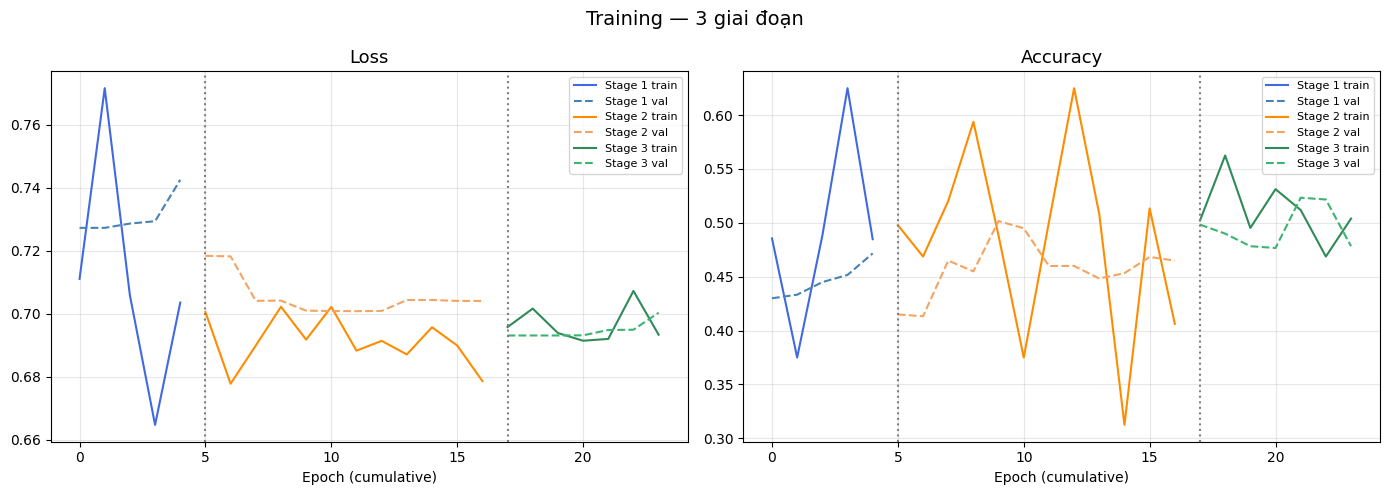

In [12]:
def plot_all_stages(h1, h2, h3):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = [('royalblue','steelblue'), ('darkorange','sandybrown'), ('seagreen','mediumseagreen')]

    for ax, metric in zip(axes, ['loss', 'accuracy']):
        offset = 0
        for i, hist in enumerate([h1, h2, h3]):
            n = len(hist.history[metric])
            x = range(offset, offset + n)
            ax.plot(x, hist.history[metric],           color=colors[i][0], label=f'Stage {i+1} train')
            ax.plot(x, hist.history[f'val_{metric}'],  color=colors[i][1], label=f'Stage {i+1} val', linestyle='--')
            if offset > 0:
                ax.axvline(offset, color='gray', linestyle=':', linewidth=1.5)
            offset += n
        ax.set_title(metric.capitalize(), fontsize=13)
        ax.set_xlabel('Epoch (cumulative)')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    plt.suptitle('Training — 3 giai đoạn', fontsize=14)
    plt.tight_layout()
    plt.show()

plot_all_stages(history_1, history_2, history_3)

## 11. Evaluation trên Test set — Full Metrics
> Chiến lược **Video-level prediction**: tổng hợp xác suất từ tất cả frame của 1 video rồi lấy mean → quyết định cuối.

In [ ]:
# Frame-level prediction 
y_prob_frames = model.predict(X_test_flat, batch_size=BATCH_SIZE, verbose=1)  # (N*frames, 2)
# class 1 = FAKE probability
fake_prob_frames = y_prob_frames[:, 1]

# Video-level aggregation (mean pooling over frames) ──
fake_prob_videos  = fake_prob_frames.reshape(n_test, n_f).mean(axis=1)  # (N,)
y_pred_videos     = (fake_prob_videos >= 0.5).astype(int)
y_true_videos     = y_test  # ground truth per video

# Metrics
print("=" * 55)
print("          EVALUATION — VIDEO LEVEL")
print("=" * 55)
print(classification_report(y_true_videos, y_pred_videos,
                             target_names=['REAL', 'FAKE'], digits=4))

auc = roc_auc_score(y_true_videos, fake_prob_videos)
ap  = average_precision_score(y_true_videos, fake_prob_videos)
print(f"ROC-AUC  : {auc:.4f}")
print(f"Avg Prec : {ap:.4f}  (AP — area under PR curve)")

19/19 ━━━━━━━━━━━━━━━━━━━━ 25s 754ms/step
          EVALUATION — VIDEO LEVEL
              precision    recall  f1-score   support

        REAL     0.6154    0.2667    0.3721        30
        FAKE     0.5319    0.8333    0.6494        30

    accuracy                         0.5500        60
   macro avg     0.5736    0.5500    0.5107        60
weighted avg     0.5736    0.5500    0.5107        60

ROC-AUC  : 0.5389
Avg Prec : 0.5462  (AP — area under PR curve)


## 12. Confusion Matrix

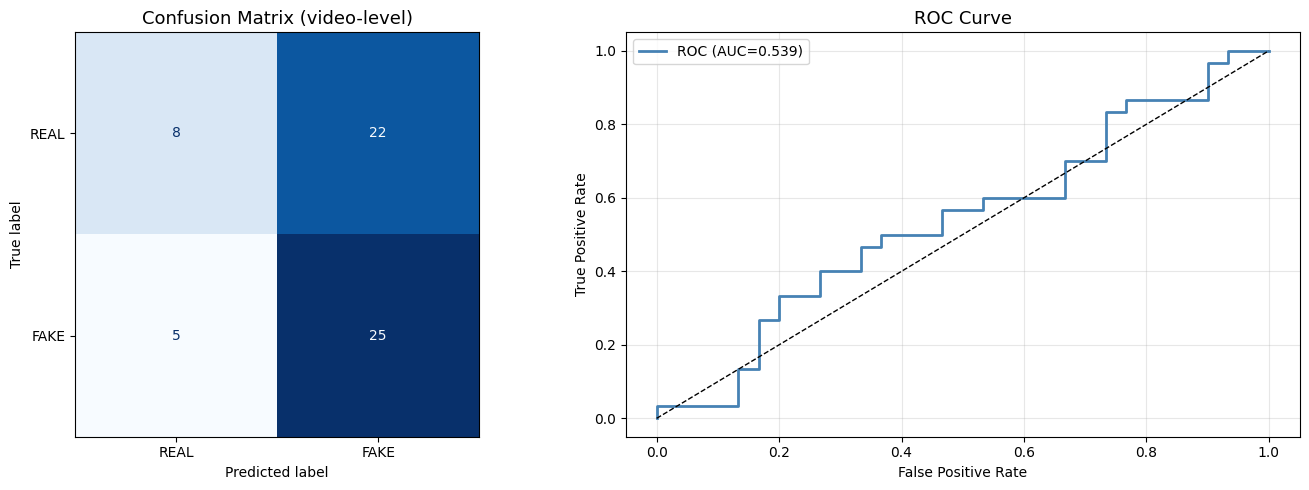

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix 
cm = confusion_matrix(y_true_videos, y_pred_videos)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['REAL', 'FAKE'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (video-level)', fontsize=13)

# ROC curve
fpr, tpr, _ = roc_curve(y_true_videos, fake_prob_videos)
axes[1].plot(fpr, tpr, lw=2, label=f'ROC (AUC={auc:.3f})', color='steelblue')
axes[1].plot([0,1],[0,1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=13)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 13. Precision-Recall Curve & Threshold Analysis

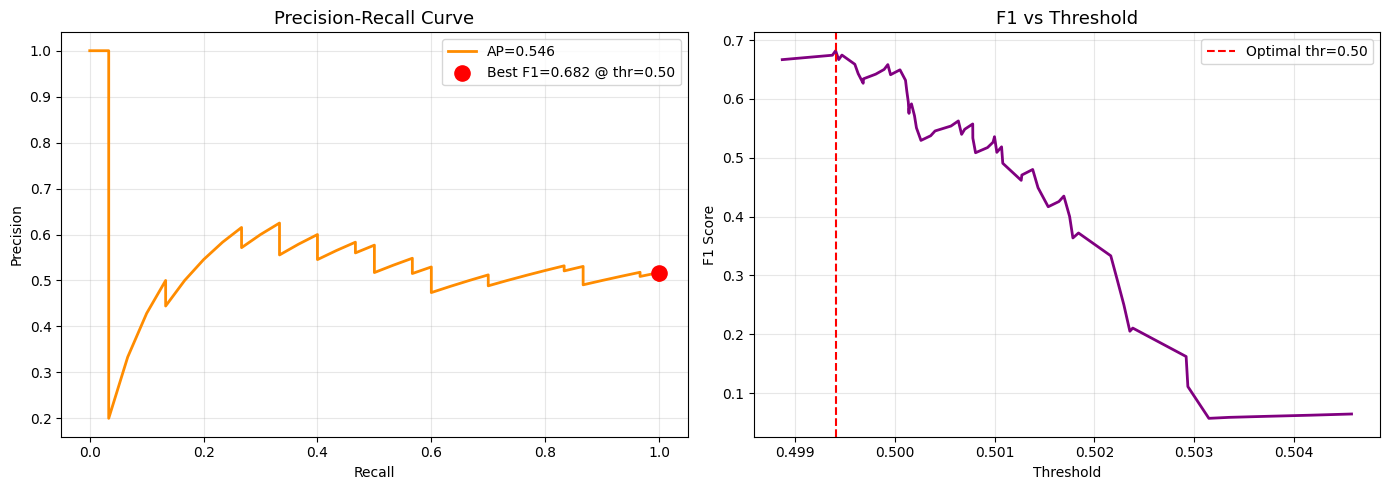


→ Threshold tối ưu theo F1: 0.4994  (F1=0.6818)
  (Dùng threshold này thay 0.5 nếu muốn balance precision/recall)


In [15]:
precision, recall, thresholds = precision_recall_curve(y_true_videos, fake_prob_videos)

# F1 tại từng threshold để tìm threshold tối ưu
f1_scores = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-8)
best_idx  = np.argmax(f1_scores)
best_thr  = thresholds[best_idx]
best_f1   = f1_scores[best_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(recall, precision, lw=2, color='darkorange', label=f'AP={ap:.3f}')
axes[0].scatter(recall[best_idx], precision[best_idx], s=120, color='red',
                zorder=5, label=f'Best F1={best_f1:.3f} @ thr={best_thr:.2f}')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve', fontsize=13)
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(thresholds, f1_scores, lw=2, color='purple')
axes[1].axvline(best_thr, color='red', linestyle='--', label=f'Optimal thr={best_thr:.2f}')
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 vs Threshold', fontsize=13)
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n→ Threshold tối ưu theo F1: {best_thr:.4f}  (F1={best_f1:.4f})")
print("  (Dùng threshold này thay 0.5 nếu muốn balance precision/recall)")

## 14. DEMO — Chọn ngẫu nhiên 1 video từ test set, cho model phán đoán
> Hiển thị từng frame, confidence bar, và verdict cuối cùng.

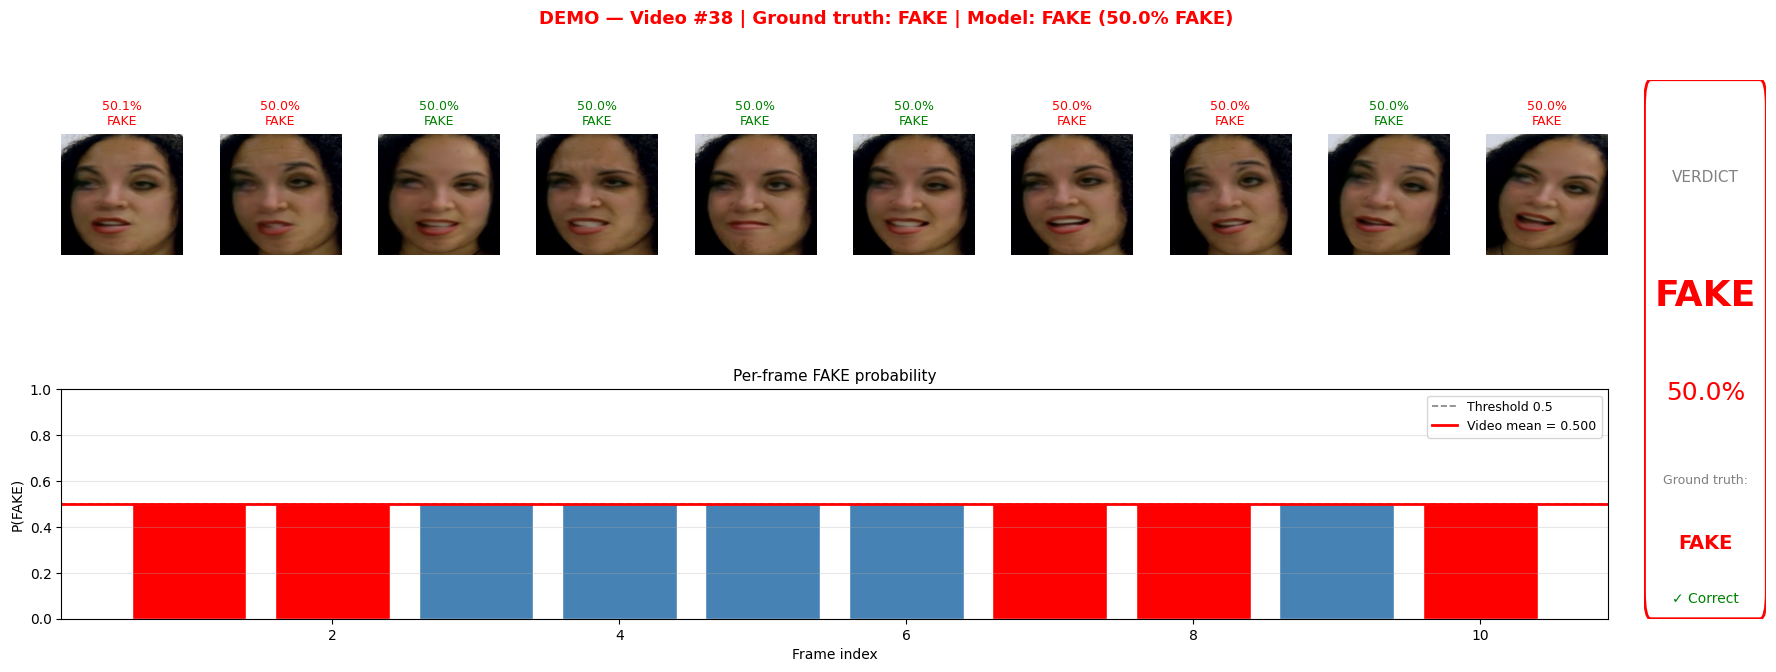

In [ ]:
# Chọn ngẫu nhiên 1 video trong test set 
demo_idx   = random.randint(0, n_test - 1)
demo_frames = X_test[demo_idx]           # shape (FRAME_COUNT, H, W, C)
demo_label  = y_test[demo_idx]           # ground truth

# Predict từng frame 
preds       = model.predict(demo_frames, verbose=0)  # (FRAME_COUNT, 2)
fake_probs  = preds[:, 1]                             # FAKE prob mỗi frame
video_score = fake_probs.mean()                       # tổng hợp

verdict      = 'FAKE' if video_score >= 0.5 else 'REAL'
verdict_col  = 'red'  if verdict == 'FAKE' else 'green'
gt_text      = label_map[demo_label]
correct      = verdict == gt_text

# Visualize
fig = plt.figure(figsize=(22, 7))
gs  = fig.add_gridspec(2, FRAME_COUNT + 1, hspace=0.35, wspace=0.3)

# Hàng trên: từng frame + confidence
for i in range(FRAME_COUNT):
    ax = fig.add_subplot(gs[0, i])
    ax.imshow(demo_frames[i])
    color = 'red' if fake_probs[i] >= 0.5 else 'green'
    ax.set_title(f"{fake_probs[i]*100:.1f}%\nFAKE", fontsize=9, color=color)
    ax.axis('off')

# Hàng dưới: bar chart của từng frame
ax_bar = fig.add_subplot(gs[1, :FRAME_COUNT])
bar_colors = ['red' if p >= 0.5 else 'steelblue' for p in fake_probs]
bars = ax_bar.bar(range(1, FRAME_COUNT+1), fake_probs, color=bar_colors, edgecolor='white')
ax_bar.axhline(0.5, color='gray', linestyle='--', linewidth=1.2, label='Threshold 0.5')
ax_bar.axhline(video_score, color=verdict_col, linestyle='-', linewidth=2,
               label=f'Video mean = {video_score:.3f}')
ax_bar.set_ylim(0, 1)
ax_bar.set_xlabel('Frame index')
ax_bar.set_ylabel('P(FAKE)')
ax_bar.set_title('Per-frame FAKE probability', fontsize=11)
ax_bar.legend(fontsize=9)
ax_bar.grid(axis='y', alpha=0.3)

# Panel verdict
ax_v = fig.add_subplot(gs[:, FRAME_COUNT])
ax_v.set_xlim(0,1); ax_v.set_ylim(0,1); ax_v.axis('off')
ax_v.add_patch(mpatches.FancyBboxPatch((0.05,0.05), 0.9, 0.9,
    boxstyle="round,pad=0.05", linewidth=2,
    edgecolor=verdict_col, facecolor='white'))
ax_v.text(0.5, 0.82, 'VERDICT',  ha='center', va='center', fontsize=11, color='gray')
ax_v.text(0.5, 0.60, verdict,    ha='center', va='center', fontsize=26,
          fontweight='bold', color=verdict_col)
ax_v.text(0.5, 0.42, f'{video_score*100:.1f}%',
          ha='center', va='center', fontsize=18, color=verdict_col)
ax_v.text(0.5, 0.25, f'Ground truth:', ha='center', fontsize=9, color='gray')
ax_v.text(0.5, 0.13, gt_text,
          ha='center', fontsize=14, fontweight='bold',
          color='green' if gt_text == 'REAL' else 'red')
ax_v.text(0.5, 0.03, '✓ Correct' if correct else '✗ Wrong',
          ha='center', fontsize=10,
          color='green' if correct else 'red')

fig.suptitle(
    f'DEMO — Video #{demo_idx} | Ground truth: {gt_text} | Model: {verdict} ({video_score*100:.1f}% FAKE)',
    fontsize=13, fontweight='bold', color=verdict_col
)
plt.show()

## 15. Demo trên video file thực tế

In [24]:
def predict_video(video_path, model, detector, frame_count=10,
                  output_size=(299,299), margin=15, threshold=0.5):
    """Predict REAL/FAKE cho 1 video file bất kỳ."""
    faces = extract_faces_from_video(video_path, detector, frame_count,
                                     output_size, margin)
    if len(faces) == 0:
        print("Không detect được mặt nào trong video!")
        return

    preds      = model.predict(faces, verbose=0)
    fake_probs = preds[:, 1]
    score      = fake_probs.mean()
    verdict    = 'FAKE' if score >= threshold else 'REAL'

    print(f"Video : {os.path.basename(video_path)}")
    print(f"Frames detect được : {len(faces)}/{frame_count}")
    print(f"Mean FAKE score    : {score:.4f}")
    print(f"Verdict            : {verdict}  ({'%.1f' % (score*100)}% FAKE)")
    return score, verdict


# ── Chạy thử trên 1 video tùy chọn ──
# Thay đường dẫn bên dưới bằng video bạn muốn test
predict_video("/kaggle/input/datasets/hungle3401/faceforensics/FF++/fake/02_09__kitchen_pan__HIH8YA82.mp4", model, detector)


Video : 02_09__kitchen_pan__HIH8YA82.mp4
Frames detect được : 10/10
Mean FAKE score    : 0.5001
Verdict            : FAKE  (50.0% FAKE)


(np.float32(0.5001364), 'FAKE')

## 16. TensorBoard
```
%load_ext tensorboard
%tensorboard --logdir /kaggle/working/logs
```